In [ ]:
# Section 1: Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# Load Dataset
# Option 1: Load from Kaggle dataset URL
# Option 2: Upload file manually

# Try loading from a direct URL first
try:
    df = pd.read_csv('https://raw.githubusercontent.com/dnation/Synthetic-Healthcare-Patient-Records-Dataset/main/synthetic_healthcare_data.csv')
    print('Loaded from GitHub URL!')
except:
    print('GitHub URL failed. Please upload file manually using the file uploader.')
    from google.colab import files
    uploaded = files.upload()
    import io
    for filename in uploaded.keys():
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
        print(f'Loaded: {filename}')

# Display basic info
print('\n=== Dataset Shape ===')
print(df.shape)

print('\n=== First 5 Rows ===')
print(df.head())

print('\n=== Column Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Dataset Info ===')
print(df.info())

GitHub URL failed. Please upload file manually using the file uploader.


Saving synthetic_healthcare_data.csv to synthetic_healthcare_data.csv
Loaded: synthetic_healthcare_data.csv

=== Dataset Shape ===
(500, 13)

=== First 5 Rows ===
  Patient_ID  Age  Gender   BMI Blood_Pressure  Cholesterol_Level Smoker  \
0       P001   20  Female  24.7       104 / 72                245     No   
1       P002   47    Male  38.5       147 / 88                268    Yes   
2       P003   21    Male  18.5       145 / 65                199     No   
3       P004   57    Male  24.1       166 / 66                271    Yes   
4       P005   28    Male  22.5       176 / 71                197    Yes   

  Diabetic     Diagnosis  Treatment_Cost Admission_Date Discharge_Date  \
0      Yes      Diabetes         3328.60     2025-01-20     2025-02-01   
1       No      Diabetes         1041.69     2025-07-01     2025-07-04   
2      Yes  Hypertension          909.11     2025-06-28     2025-07-06   
3      Yes  Hypertension         1920.12     2025-02-10     2025-02-18   
4       No

In [ ]:
# Section 2: Data Cleaning & Preprocessing

# Make a copy of original dataframe
df_clean = df.copy()

# 1. Strip whitespace from string columns
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].astype(str).str.strip()

# 2. Fix Outcome typo: Deceases -> Deceased
df_clean['Outcome'] = df_clean['Outcome'].replace('Deceases', 'Deceased')

# 3. Parse dates
df_clean['Admission_Date'] = pd.to_datetime(df_clean['Admission_Date'], errors='coerce')
df_clean['Discharge_Date'] = pd.to_datetime(df_clean['Discharge_Date'], errors='coerce')

# 4. Convert numeric columns
numeric_cols = ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 5. Fill missing values
# Numeric: median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['BMI'].fillna(df_clean['BMI'].median(), inplace=True)
df_clean['Cholesterol_Level'].fillna(df_clean['Cholesterol_Level'].median(), inplace=True)
df_clean['Treatment_Cost'].fillna(df_clean['Treatment_Cost'].median(), inplace=True)

# Categorical: mode
df_clean['Gender'].fillna(df_clean['Gender'].mode()[0], inplace=True)
df_clean['Diagnosis'].fillna(df_clean['Diagnosis'].mode()[0], inplace=True)
df_clean['Smoker'].fillna(df_clean['Smoker'].mode()[0], inplace=True)
df_clean['Diabetic'].fillna(df_clean['Diabetic'].mode()[0], inplace=True)
df_clean['Outcome'].fillna(df_clean['Outcome'].mode()[0], inplace=True)

print('Data cleaning completed!')
print(f'Shape: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print(f'\nUnique Outcomes: {df_clean["Outcome"].unique()}')

Data cleaning completed!
Shape: (500, 13)
Missing values: 0

Unique Outcomes: ['Recovered' 'Referred' 'Deceased']


In [ ]:
# Section 3: Feature Engineering

# 1. Length of Stay (in days)
df_clean['Length_of_Stay'] = (df_clean['Discharge_Date'] - df_clean['Admission_Date']).dt.days
df_clean['Length_of_Stay'].fillna(df_clean['Length_of_Stay'].median(), inplace=True)

# 2. Split Blood Pressure into Systolic and Diastolic
def split_bp(bp_string):
    try:
        parts = str(bp_string).split('/')
        systolic = int(parts[0].strip())
        diastolic = int(parts[1].strip())
        return pd.Series([systolic, diastolic])
    except:
        return pd.Series([np.nan, np.nan])

bp_split = df_clean['Blood_Pressure'].apply(split_bp)
df_clean['Systolic_BP'] = bp_split[0]
df_clean['Diastolic_BP'] = bp_split[1]

# Fill BP missing values
df_clean['Systolic_BP'].fillna(df_clean['Systolic_BP'].median(), inplace=True)
df_clean['Diastolic_BP'].fillna(df_clean['Diastolic_BP'].median(), inplace=True)

# 3. Age Group
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle'
    elif age < 65:
        return 'Senior'
    else:
        return 'Elderly'

df_clean['Age_Group'] = df_clean['Age'].apply(age_group)

# 4. High Cost Flag (above median)
median_cost = df_clean['Treatment_Cost'].median()
df_clean['High_Cost'] = (df_clean['Treatment_Cost'] > median_cost).astype(int)

# 5. High BP Flag
df_clean['High_BP'] = ((df_clean['Systolic_BP'] > 140) | (df_clean['Diastolic_BP'] > 90)).astype(int)

print('Feature Engineering completed!')
print(f'Total columns: {df_clean.shape[1]}')
print(df_clean.head())

Feature Engineering completed!
Total columns: 19
  Patient_ID  Age  Gender   BMI Blood_Pressure  Cholesterol_Level Smoker  \
0       P001   20  Female  24.7       104 / 72                245     No   
1       P002   47    Male  38.5       147 / 88                268    Yes   
2       P003   21    Male  18.5       145 / 65                199     No   
3       P004   57    Male  24.1       166 / 66                271    Yes   
4       P005   28    Male  22.5       176 / 71                197    Yes   

  Diabetic     Diagnosis  Treatment_Cost Admission_Date Discharge_Date  \
0      Yes      Diabetes         3328.60     2025-01-20     2025-02-01   
1       No      Diabetes         1041.69     2025-07-01     2025-07-04   
2      Yes  Hypertension          909.11     2025-06-28     2025-07-06   
3      Yes  Hypertension         1920.12     2025-02-10     2025-02-18   
4       No           Flu         3224.12     2025-04-18     2025-04-27   

     Outcome  Length_of_Stay  Systolic_BP  Diasto

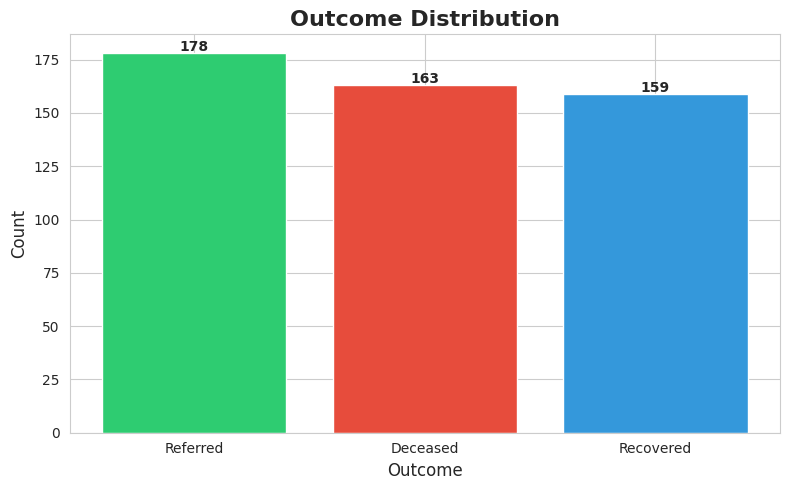

<Figure size 800x500 with 0 Axes>

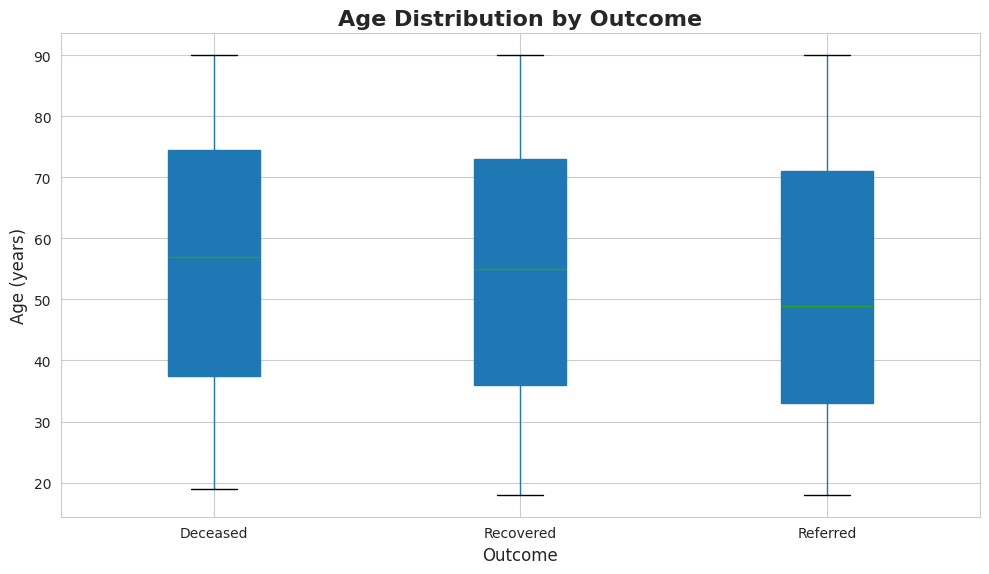

<Figure size 800x500 with 0 Axes>

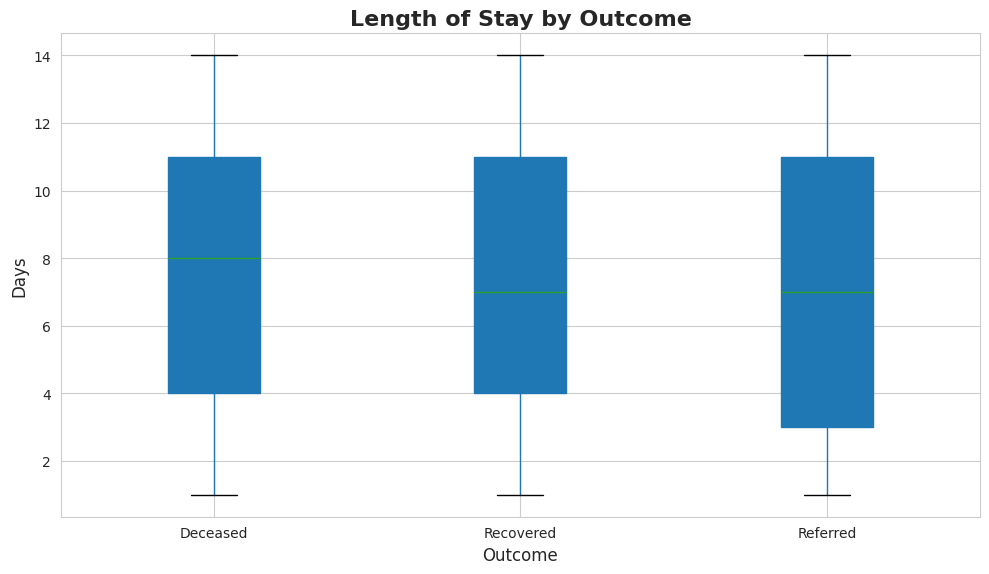

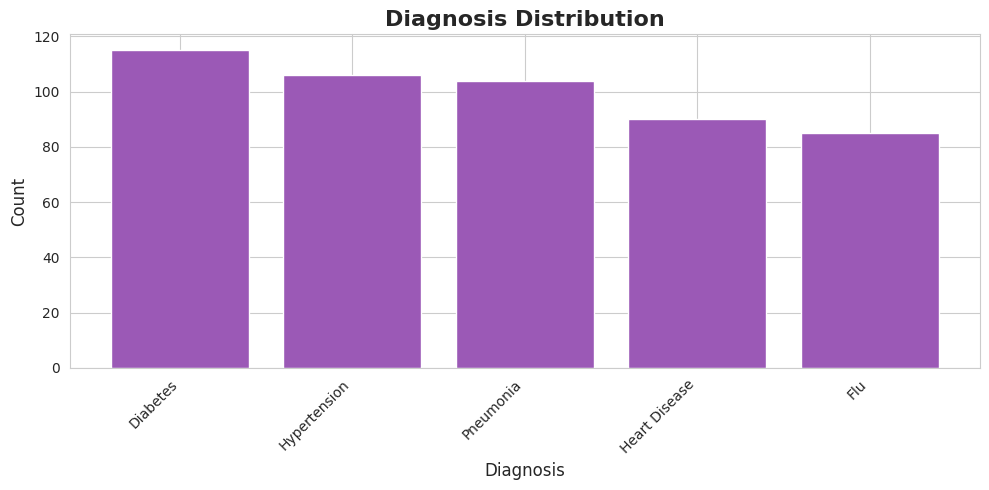

In [ ]:
# Section 4: Exploratory Data Analysis (EDA)

# Plot 1: Outcome Distribution
plt.figure(figsize=(8, 5))
outcome_counts = df_clean['Outcome'].value_counts()
plt.bar(outcome_counts.index, outcome_counts.values, color=['#2ecc71', '#e74c3c', '#3498db'])
plt.title('Outcome Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(outcome_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Age Distribution by Outcome
plt.figure(figsize=(8, 5))
df_clean.boxplot(column='Age', by='Outcome', patch_artist=True)
plt.title('Age Distribution by Outcome', fontsize=16, fontweight='bold')
plt.suptitle('')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3: Length of Stay by Outcome
plt.figure(figsize=(8, 5))
df_clean.boxplot(column='Length_of_Stay', by='Outcome', patch_artist=True)
plt.title('Length of Stay by Outcome', fontsize=16, fontweight='bold')
plt.suptitle('')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Days', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 4: Diagnosis Distribution
plt.figure(figsize=(10, 5))
diag_counts = df_clean['Diagnosis'].value_counts()
plt.bar(diag_counts.index, diag_counts.values, color='#9b59b6')
plt.title('Diagnosis Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature columns: ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost', 'Length_of_Stay', 'Systolic_BP', 'Diastolic_BP', 'Gender', 'Smoker', 'Diabetic', 'Diagnosis', 'Age_Group', 'High_Cost', 'High_BP']
Target classes: ['Deceased' 'Recovered' 'Referred']
Training set size: 400
Test set size: 100
Scaled training shape: (400, 24)
Scaled test shape: (100, 24)

=== Logistic Regression ===
Accuracy: 0.3900
Macro F1-Score: 0.3750

Classification Report:
              precision    recall  f1-score   support

    Deceased       0.33      0.27      0.30        33
   Recovered       0.47      0.28      0.35        32
    Referred       0.39      0.60      0.47        35

    accuracy                           0.39       100
   macro avg       0.40      0.38      0.37       100
weighted avg       0.40      0.39      0.38       100


=== Random Forest ===
Accuracy: 0.3200
Macro F1-Score: 0.3106

Classification Report:
              precision    recall  f1-score   support

    Deceased       0.29   

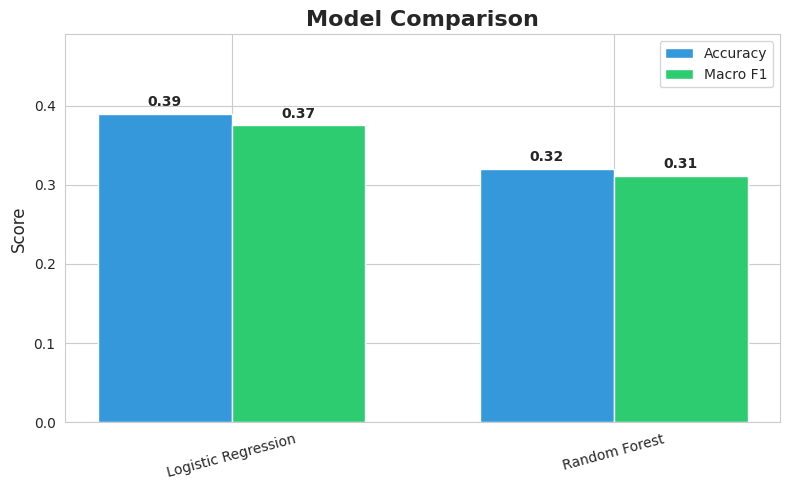

In [ ]:
# Section 5: Model Training

# Prepare features and target
feature_cols = ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
                'Length_of_Stay', 'Systolic_BP', 'Diastolic_BP',
                'Gender', 'Smoker', 'Diabetic', 'Diagnosis',
                'Age_Group', 'High_Cost', 'High_BP']

X = df_clean[feature_cols].copy()
y = df_clean['Outcome'].copy()

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Feature columns:', feature_cols)
print('Target classes:', le.classes_)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

# Define preprocessing for numeric and categorical columns
numeric_features = ['Age', 'BMI', 'Cholesterol_Level', 'Treatment_Cost',
                    'Length_of_Stay', 'Systolic_BP', 'Diastolic_BP', 'High_Cost', 'High_BP']
categorical_features = ['Gender', 'Smoker', 'Diabetic', 'Diagnosis', 'Age_Group']

numeric_transformer = StandardScaler()
categorical_transformer = Pipeline(steps=[
    ('onehot', pd.get_dummies)  # will use ColumnTransformer differently
])

# We will use get_dummies directly
X_train_cat = pd.get_dummies(X_train, columns=categorical_features, drop_first=False)
X_test_cat = pd.get_dummies(X_test, columns=categorical_features, drop_first=False)

# Align columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train_cat.copy()
X_test_scaled = X_test_cat.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train_cat[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_cat[numeric_features])

print(f'Scaled training shape: {X_train_scaled.shape}')
print(f'Scaled test shape: {X_test_scaled.shape}')

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f'\n=== Logistic Regression ===')
print(f'Accuracy: {acc_lr:.4f}')
print(f'Macro F1-Score: {f1_lr:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f'\n=== Random Forest ===')
print(f'Accuracy: {acc_rf:.4f}')
print(f'Macro F1-Score: {f1_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Compare models
print('\n=== Model Comparison ===')
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_lr, acc_rf]
f1_scores = [f1_lr, f1_rf]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Macro F1': f1_scores
})
print(comparison_df)

# Plot comparison
plt.figure(figsize=(8, 5))
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, f1_scores, width, label='Macro F1', color='#2ecc71')
plt.xticks(x, models, rotation=15)
plt.title('Model Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.legend()
for i, v in enumerate(accuracies):
    plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)
for i, v in enumerate(f1_scores):
    plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)
plt.ylim(0, max(max(accuracies), max(f1_scores)) + 0.1)
plt.tight_layout()
plt.show()

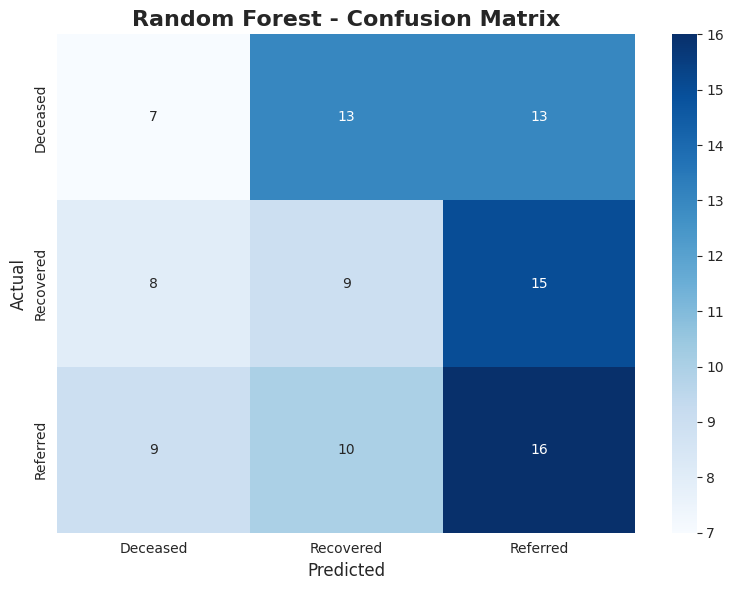

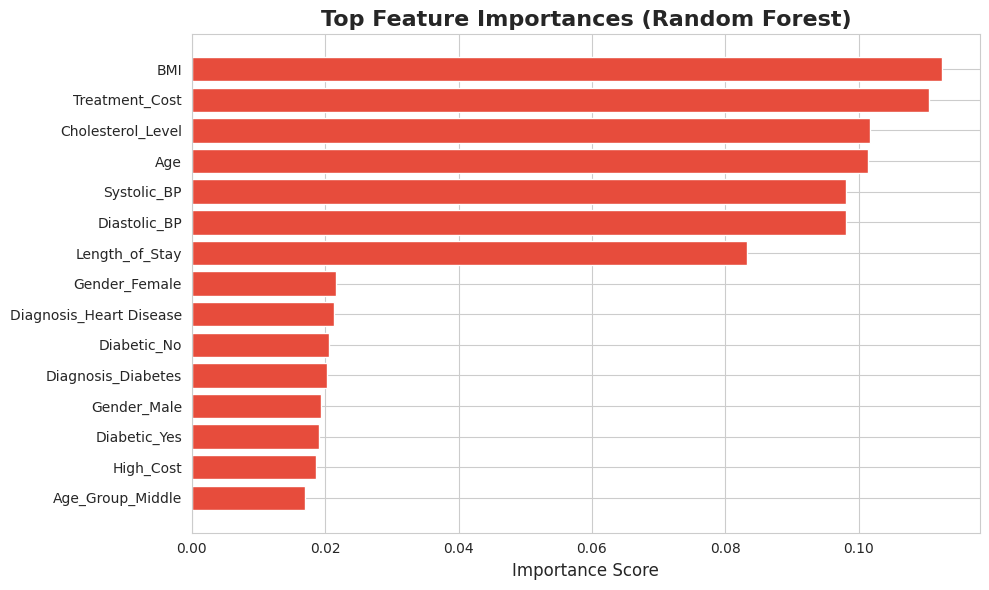

Top 10 Most Important Features:
                    Feature  Importance
1                       BMI    0.112595
3            Treatment_Cost    0.110537
2         Cholesterol_Level    0.101724
0                       Age    0.101431
5               Systolic_BP    0.098104
6              Diastolic_BP    0.098097
4            Length_of_Stay    0.083206
9             Gender_Female    0.021691
17  Diagnosis_Heart Disease    0.021322
13              Diabetic_No    0.020562

FINAL MODEL SUMMARY
Best Model: Logistic Regression
Total Features Used: 14
Training Samples: 400
Test Samples: 100
Test Accuracy (LR): 0.3900
Test Accuracy (RF): 0.3200
Test Macro F1 (LR): 0.3750
Test Macro F1 (RF): 0.3106


In [ ]:
# Section 6: Results & Feature Importance

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Feature Importance from Random Forest
feature_names = X_train_scaled.columns.tolist()
importances = rf.feature_importances_

# Create DataFrame and sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
top_n = min(15, len(fi_df))
fi_top = fi_df.head(top_n)
plt.barh(fi_top['Feature'], fi_top['Importance'], color='#e74c3c')
plt.gca().invert_yaxis()
plt.title('Top Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(fi_df.head(10))

# Summary Table
print('\n' + '='*50)
print('FINAL MODEL SUMMARY')
print('='*50)
print(f'Best Model: Random Forest' if acc_rf > acc_lr else 'Best Model: Logistic Regression')
print(f'Total Features Used: {len(feature_cols)}')
print(f'Training Samples: {X_train.shape[0]}')
print(f'Test Samples: {X_test.shape[0]}')
print(f'Test Accuracy (LR): {acc_lr:.4f}')
print(f'Test Accuracy (RF): {acc_rf:.4f}')
print(f'Test Macro F1 (LR): {f1_lr:.4f}')
print(f'Test Macro F1 (RF): {f1_rf:.4f}')
print('='*50)